# 🏥 Projet de Machine Learning – Analyse et Prédiction du Diabète

## 📌 Introduction Générale

Le diabète est une maladie chronique qui constitue un enjeu majeur de santé publique dans le monde. Une détection précoce et un suivi médical efficace permettent de réduire les complications graves ainsi que les coûts hospitaliers.

Dans ce projet, nous appliquons des techniques de Machine Learning sur deux jeux de données réels afin d’étudier deux problématiques complémentaires liées au diabète.

---

## 🎯 Objectif Global du Projet

L’objectif principal est d’utiliser des modèles de Machine Learning pour :

- Détecter la présence du diabète chez un patient à partir de données médicales.
- Prédire la réadmission hospitalière des patients diabétiques.

Le projet suit les étapes fondamentales d’un processus de Data Science :

1. Business Understanding  
2. Data Understanding (Analyse Exploratoire des Données)  
3. Data Preparation  
4. Modeling  
5. Évaluation des modèles  

---

# 📁 Description des Jeux de Données

Ce projet utilise deux jeux de données liés au diabète afin de traiter deux problématiques différentes en Machine Learning.

---

## 🔵 1️⃣ Dataset : Pima Indians Diabetes Database

Ce dataset contient des données médicales de patientes adultes utilisées pour la détection du diabète.

### 📌 Objectif du dataset
Prédire si une personne est atteinte de diabète ou non.

### 📊 Variables principales
- Pregnancies (nombre de grossesses)
- Glucose (niveau de glucose)
- BloodPressure (pression artérielle)
- SkinThickness (épaisseur de la peau)
- Insulin (niveau d’insuline)
- BMI (indice de masse corporelle)
- DiabetesPedigreeFunction (facteur génétique)
- Age (âge du patient)
- Outcome (variable cible : 0 = non diabétique, 1 = diabétique)

### 🎯 Type de problème
Classification binaire supervisée.

---

## 🔵 2️⃣ Dataset : Diabetes 130-US Hospitals (1999–2008)

Ce dataset contient des informations hospitalières réelles collectées dans 130 hôpitaux aux États-Unis entre 1999 et 2008.

### 📌 Objectif du dataset
Prédire la réadmission hospitalière des patients diabétiques.

### 📊 Types de variables
- Données démographiques (âge, sexe, race)
- Informations d’admission (type d’admission, durée d’hospitalisation)
- Examens médicaux
- Traitements médicamenteux
- Nombre de visites précédentes
- Diagnostics médicaux

### 🎯 Variable cible
readmitted :
- NO → Pas de réadmission
- <30 → Réadmission en moins de 30 jours
- >30 → Réadmission après 30 jours

### 🎯 Type de problème
Classification multi-classes supervisée.

# **==============================================================**
# 🏥 Business Understanding & Data Understanding
# **==============================================================**


# 🔵 1️⃣ Dataset 1 : Détection du Diabète  

## 🎯 Business Objective (BO)

Développer un système capable d’aider au diagnostic précoce du diabète afin d’améliorer la prévention et la prise en charge médicale.

## 🎯 Data Science Objective (DSO)

Construire un modèle de classification supervisée permettant de prédire si un patient est :

- Diabétique (1)
- Non diabétique (0)

Type de problème : **Classification binaire**

---

## 📊 Data Understanding – Analyse Exploratoire (EDA)

Dans cette étape, nous allons :

- Vérifier la structure des données (df.info())
- Identifier les valeurs manquantes
- Étudier la distribution des variables
- Analyser la variable cible (Outcome)
- Visualiser les relations entre les variables
- Utiliser des graphiques :
  - Histogrammes
  - Boxplots
  - Heatmap de corrélation
  - Countplot

L’objectif est de comprendre les données avant la modélisation.

---

# 🔵 2️⃣ Dataset 2 : Réadmission Hospitalière  

## 🎯 Business Objective (BO)

Réduire le taux de réadmission hospitalière des patients diabétiques afin d’améliorer la qualité des soins et réduire les coûts médicaux.

## 🎯 Data Science Objective (DSO)

Construire un modèle capable de prédire la réadmission d’un patient diabétique :

- NO → Pas de réadmission
- <30 → Réadmission en moins de 30 jours
- >30 → Réadmission après 30 jours

Type de problème : **Classification multi-classes supervisée**

---

## 📊 Data Understanding – Analyse Exploratoire (EDA)

Dans cette étape, nous allons :

- Analyser la structure des données (df.info())
- Identifier et traiter les valeurs manquantes
- Étudier la distribution de la variable cible (readmitted)
- Vérifier le déséquilibre des classes
- Analyser les variables importantes :
  - time_in_hospital
  - num_medications
  - number_inpatient
  - age
- Visualiser les relations à l’aide de :
  - Bar plots
  - Countplots
  - Boxplots
  - Heatmap de corrélation

L’objectif est de comprendre les facteurs influençant la réadmission avant la modélisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage plus propre des graphiques
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# 🔹 Réduction de dimension
from sklearn.decomposition import PCA

# 🔹 Clustering (non supervisé)
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# 🔹 Modèles supervisés
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'numpy'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (8).csv
Saving diabetic_data.csv to diabetic_data (8).csv


In [ ]:
import pandas as pd

df_pima = pd.read_csv("diabetes.csv")

df_hospital = pd.read_csv("diabetic_data.csv")

print("Pima Shape:", df_pima.shape)
print("Hospital Shape:", df_hospital.shape)

Pima Shape: (768, 9)
Hospital Shape: (101766, 50)


# 🟢 🔵 DATASET 1 — Détection du Diabète (Pima)

In [ ]:
df_pima.info()
df_pima.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df_pima.head(10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
(df_pima == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


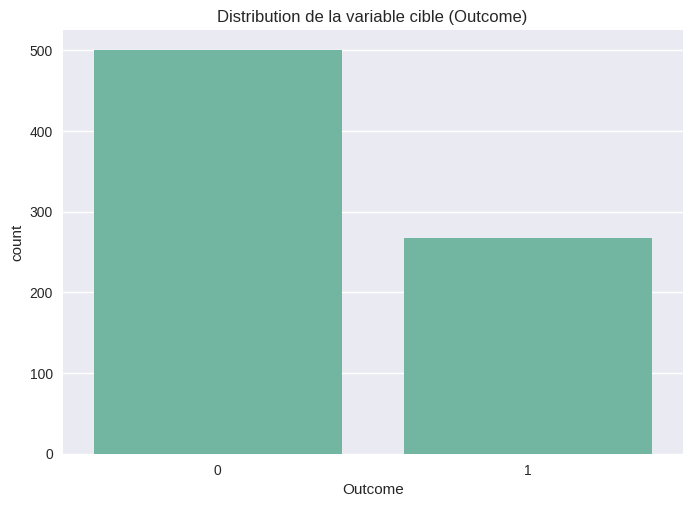

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df_pima)
plt.title("Distribution de la variable cible (Outcome)")
plt.show()

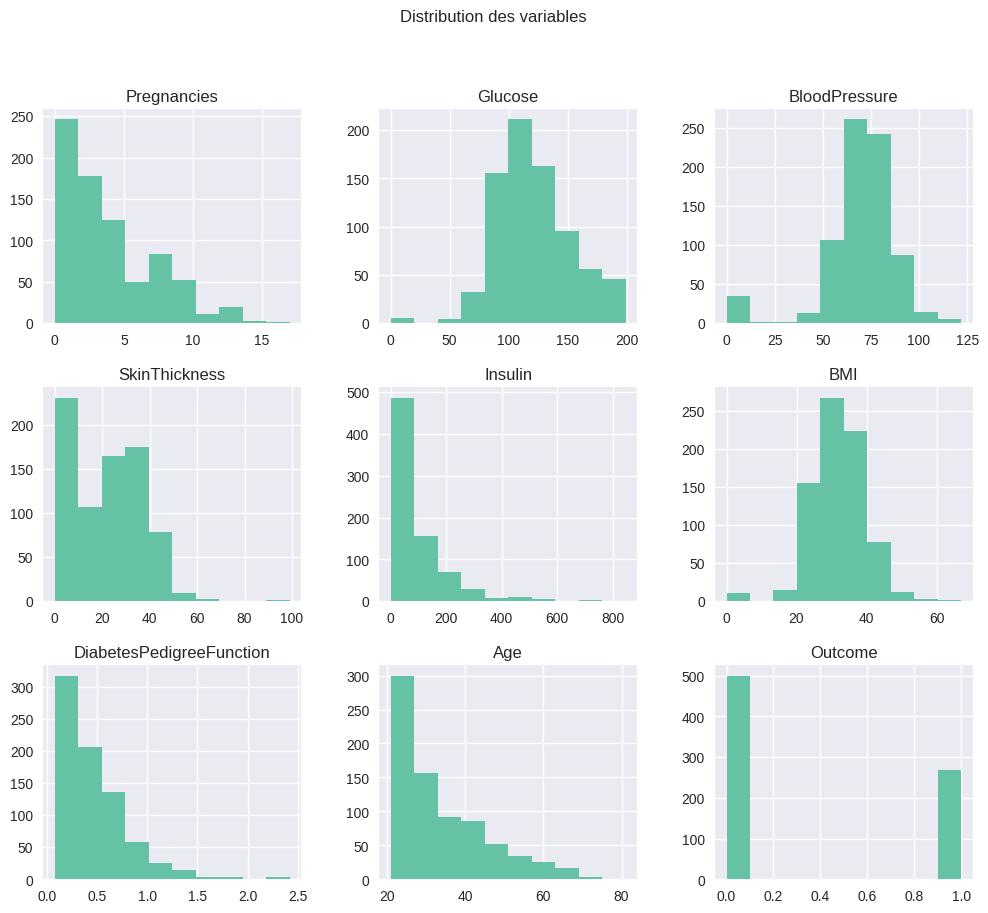

In [ ]:
df_pima.hist(figsize=(12,10))
plt.suptitle("Distribution des variables")
plt.show()

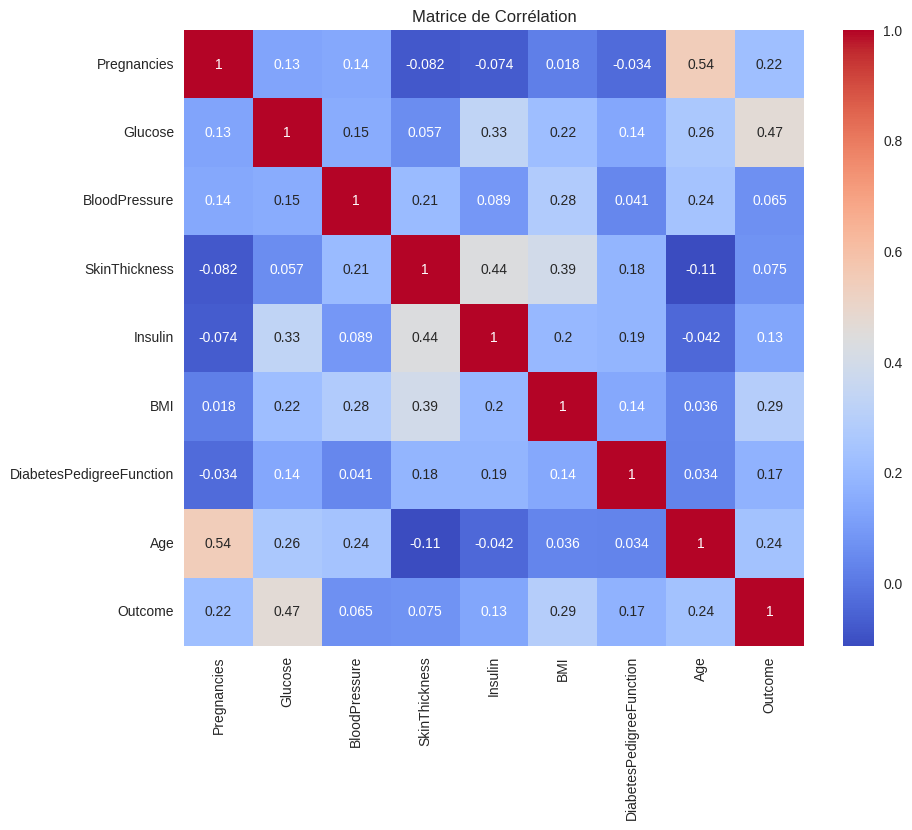

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_pima.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de Corrélation")
plt.show()

# 🟢 🔵 DATASET 2 — Réadmission Hospitalière

In [ ]:
df_hospital.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df_hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df_hospital = df_hospital.replace("?", np.nan)

df_hospital.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


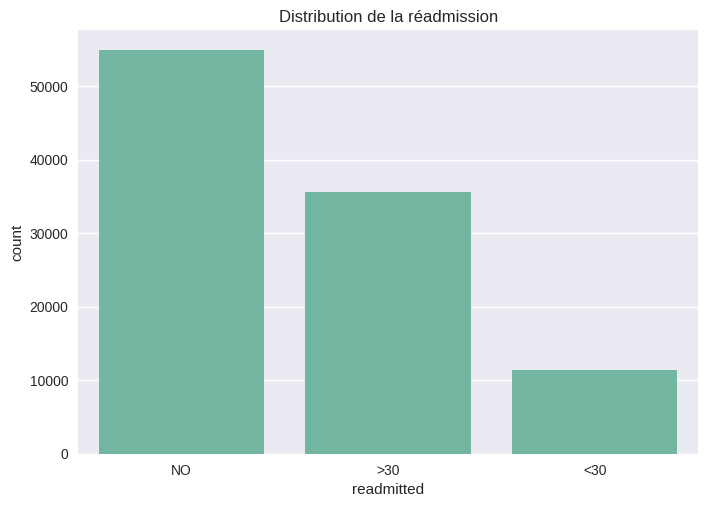

In [ ]:
sns.countplot(x="readmitted", data=df_hospital)
plt.title("Distribution de la réadmission")
plt.show()

In [ ]:
df_hospital["readmitted"].value_counts(normalize=True)

,proportion
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


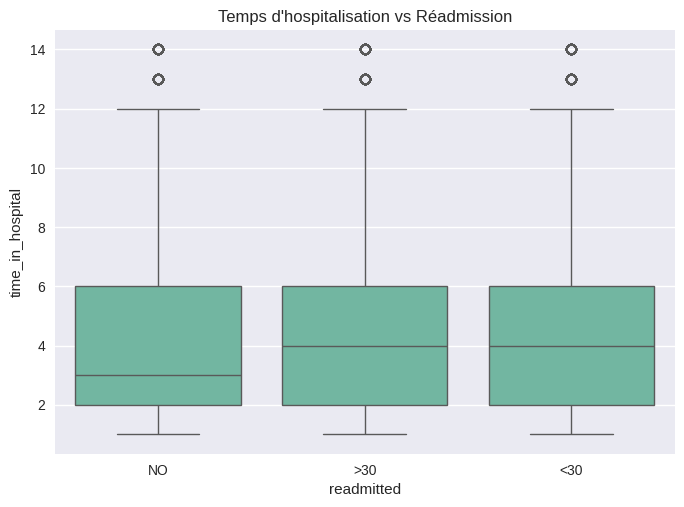

In [ ]:
sns.boxplot(x="readmitted", y="time_in_hospital", data=df_hospital)
plt.title("Temps d'hospitalisation vs Réadmission")
plt.show()

# **==============================================================**
# **🟢 🔵 PARTIE DATA PREPARATION**
# **==============================================================**

# 🧹 Data Preparation (Nettoyage et Préparation des Données)

Dans cette étape, nous préparons les données pour les modèles de Machine Learning.

Cette phase est très importante car la qualité des données influence directement la performance du modèle.

Les objectifs de cette étape sont :

- Supprimer les variables inutiles
- Traiter les valeurs manquantes
- Encoder les variables catégorielles
- Normaliser les variables numériques
- Séparer les données en ensemble d'entraînement et de test

À la fin de cette étape, les données seront prêtes pour la modélisation.

# **🟢 🔵 DATASET 1 — PIMA (Détection du Diabète)**

In [ ]:
# Remplacer les valeurs 0 non réalistes par NaN
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    df_pima[col] = df_pima[col].replace(0, np.nan)

# Remplir les valeurs manquantes par la médiane
# Pour l'imputation, nous choisissons la médiane (≈125) car :
# 1. Elle est robuste aux valeurs extrêmes (contrairement à la moyenne).
# 2. Elle conserve la distribution générale des données.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df_pima[cols_with_zero] = imputer.fit_transform(df_pima[cols_with_zero])

# Vérification
df_pima.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### 📏 Normalisation des Données

La normalisation est nécessaire pour les modèles sensibles à l'échelle des variables :

- SVM
- KNN
- PCA

Nous utilisons StandardScaler pour mettre toutes les variables sur la même échelle.

In [ ]:
from sklearn.preprocessing import StandardScaler

X_pima = df_pima.drop("Outcome", axis=1)
y_pima = df_pima["Outcome"]

scaler = StandardScaler()
X_pima_scaled = scaler.fit_transform(X_pima)

In [ ]:
X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima_scaled, y_pima,
    test_size=0.2,
    random_state=42
)

# **🟢 🔵 DATASET 2 — Hospital (Réadmission)**

In [ ]:
missing_percent = df_hospital.isnull().sum() / len(df_hospital) * 100
missing_percent.sort_values(ascending=False)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
patient_nbr,0.000000


In [ ]:
cols_to_drop = missing_percent[missing_percent > 80].index

df_hospital.drop(columns=cols_to_drop, inplace=True)

print("Colonnes supprimées :", list(cols_to_drop))
print("Nouvelle dimension :", df_hospital.shape)

Colonnes supprimées : ['weight', 'max_glu_serum', 'A1Cresult']
Nouvelle dimension : (101766, 47)


In [ ]:
df_hospital.drop(columns=["encounter_id", "patient_nbr"],
                 inplace=True,
                 errors="ignore")

print("Dimension après suppression des IDs :", df_hospital.shape)

Dimension après suppression des IDs : (101766, 45)


In [ ]:
df_hospital = df_hospital.replace("?", np.nan)

# Remplacer les valeurs manquantes des variables catégorielles
categorical_cols = df_hospital.select_dtypes(include="object").columns

for col in categorical_cols:
    df_hospital[col] = df_hospital[col].fillna("Unknown")

print("Total valeurs manquantes après traitement :")
print(df_hospital.isnull().sum().sum())

Total valeurs manquantes après traitement :
0


### 🔄 Encodage des Variables Catégorielles

Les modèles de Machine Learning ne peuvent pas travailler directement avec du texte.

Nous utilisons donc l'encodage One-Hot Encoding pour transformer les variables catégorielles en variables numériques.

In [ ]:
X_hospital = df_hospital.drop("readmitted", axis=1)
y_hospital = df_hospital["readmitted"]

In [ ]:
X_hospital = pd.get_dummies(X_hospital, drop_first=True)

print("Nombre de colonnes après encodage :", X_hospital.shape[1])

Nombre de colonnes après encodage : 2419


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_hospital_scaled = scaler.fit_transform(X_hospital)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hospital_scaled,
    y_hospital,
    test_size=0.2,
    random_state=42
)

print("Taille Train :", X_train_h.shape)
print("Taille Test :", X_test_h.shape)

Taille Train : (81412, 2419)
Taille Test : (20354, 2419)


# **🟢 🔎 Vérification des Données Après Nettoyage**

# 🔎 Vérification des Données Après Nettoyage

Après l’étape de Data Preparation, nous devons vérifier que :

- Les valeurs manquantes ont été traitées
- Les colonnes inutiles ont été supprimées
- Les variables catégorielles ont été encodées
- Les données sont prêtes pour la modélisation

Cette étape permet de s'assurer que le dataset est propre et cohérent avant d’appliquer les modèles de Machine Learning.

# **🟢 🔵 DATASET 1 — Pima (Détection du Diabète)**

In [ ]:
df_pima.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1


In [ ]:
print("Valeurs manquantes :")
print(df_pima.isnull().sum().sum())

Valeurs manquantes :
0


In [ ]:
df_pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
df_pima.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **🟢 🔵 DATASET 2 — Hospital (Réadmission)**

In [ ]:
df_hospital.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,Unknown,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,Unknown,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,Unknown,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,Unknown,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,Unknown,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,[50-60),2,1,2,3,Unknown,Unknown,31,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,Caucasian,Male,[60-70),3,1,2,4,Unknown,Unknown,70,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,Caucasian,Male,[70-80),1,1,7,5,Unknown,Unknown,73,...,No,No,No,No,No,No,No,No,Yes,>30
8,Caucasian,Female,[80-90),2,1,4,13,Unknown,Unknown,68,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,Caucasian,Female,[90-100),3,3,4,12,Unknown,InternalMedicine,33,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("Valeurs manquantes :")
print(df_hospital.isnull().sum().sum())

Valeurs manquantes :
0


In [ ]:
print("Nombre de colonnes après encodage :")
print(df_hospital.shape[1])

Nombre de colonnes après encodage :
45


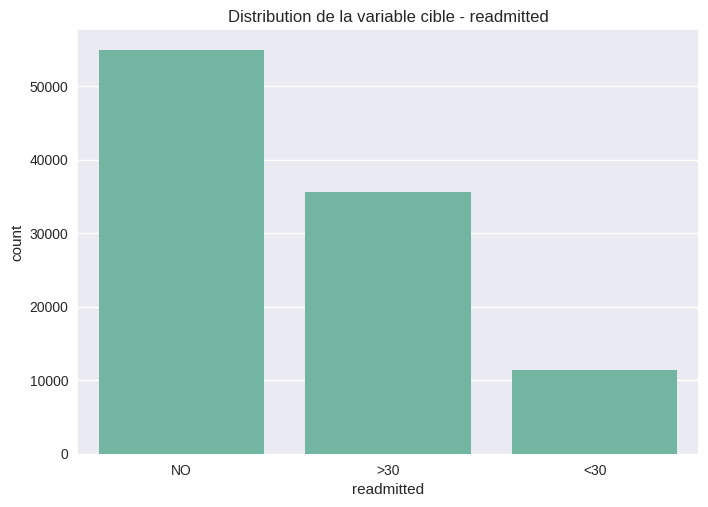

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_hospital)
plt.title("Distribution de la variable cible - readmitted")
plt.show()

In [ ]:
df_hospital["readmitted"].value_counts(normalize=True)

,proportion
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


# **==============================================================**
# **🟣 PARTIE MODELING**
# **==============================================================**

# 🤖 Modeling

Dans cette étape, nous appliquons plusieurs algorithmes de Machine Learning :

## Modèles non supervisés :
- ACP (PCA)
- K-Means
- DBSCAN

## Modèles supervisés :
- SVM
- KNN
- Arbre de décision
- Régression linéaire

L’objectif est de comparer les performances et analyser les résultats.

# **🟢 🔵 1️⃣ ACP (PCA)**

Variance expliquée : [0.00151251 0.00138557]
Variance totale expliquée : 0.0028980822744401136


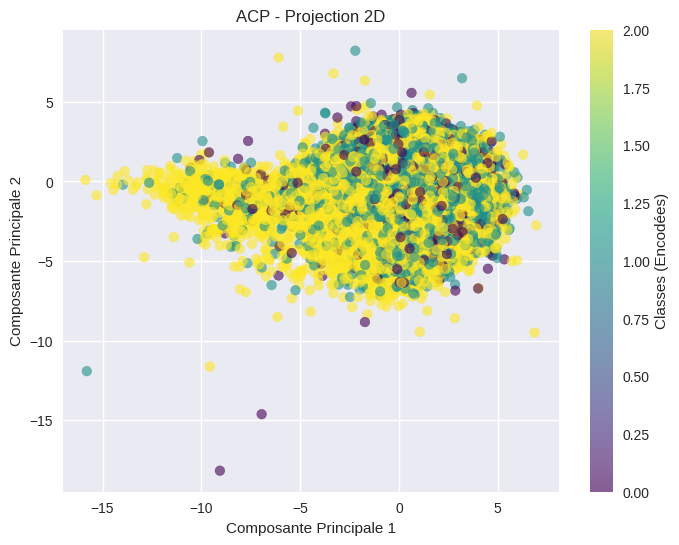

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 🔹 Encoder la variable cible
# ==============================
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_h)

# ==============================
# 🔹 PCA pour visualisation 2D
# ==============================
# On garde 2 composantes pour le plot
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_h)
X_test_pca = pca.transform(X_test_h)

print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale expliquée :",
      np.sum(pca.explained_variance_ratio_))

# ==============================
# 🔹 Visualisation
# ==============================
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train_encoded,
    cmap='viridis',
    alpha=0.6
)

plt.colorbar(scatter, label="Classes (Encodées)")
plt.title("ACP - Projection 2D")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.show()

# **🟢 🔵 2️⃣ K-Means**

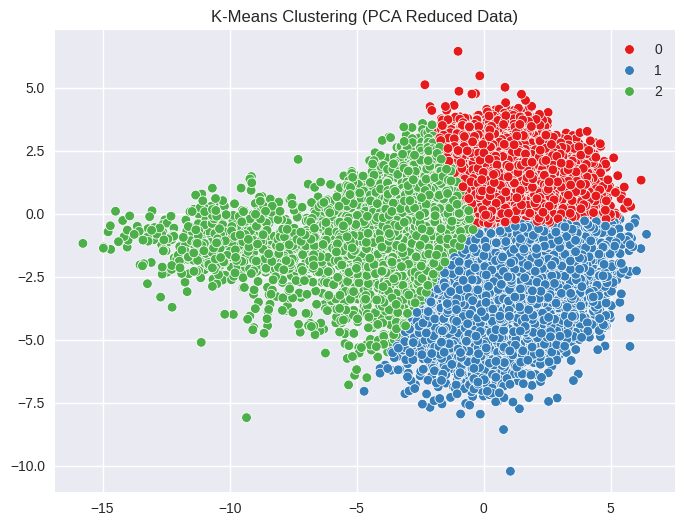

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Réduction à 2 dimensions pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hospital_scaled)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Visualisation
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1")
plt.title("K-Means Clustering (PCA Reduced Data)")
plt.show()

# **🟢 🔵 3️⃣ DBSCAN**

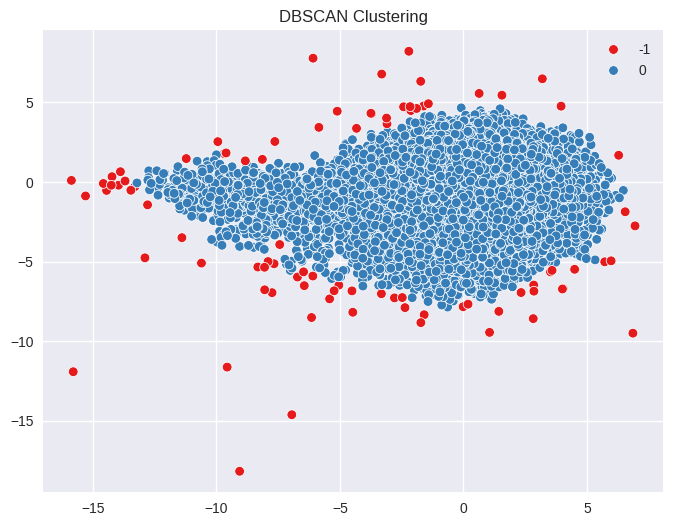

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_train_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=db_labels,
    palette="Set1"
)
plt.title("DBSCAN Clustering")
plt.show()

# **🟢 🔵 4️⃣ SVM**

Accuracy SVM : 0.379


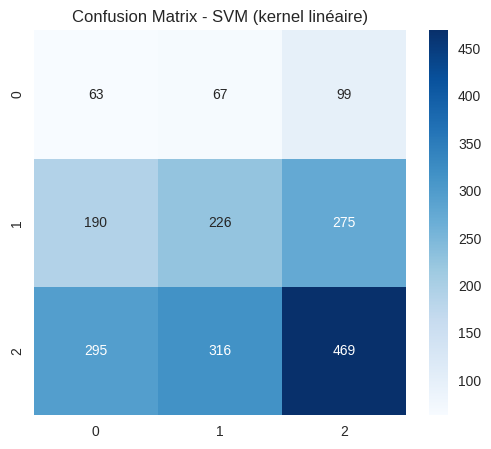

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# ⚠️ Échantillon pour accélérer l'exécution
df_sample = df_hospital.sample(10000, random_state=42)

# Séparer features et target
X_h = df_sample.drop("readmitted", axis=1)
y_h = df_sample["readmitted"]

# Encoder les variables catégorielles (texte)
X_h_encoded = pd.get_dummies(X_h, drop_first=True)

# Normalisation
scaler = StandardScaler()
X_h_scaled = scaler.fit_transform(X_h_encoded)

# Split train/test
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h_scaled, y_h, test_size=0.2, random_state=42
)

# ✅ SVM avec kernel linéaire
svm = SVC(kernel="linear", max_iter=2000)
svm.fit(X_train_h, y_train_h)

# Prédictions
y_pred_svm = svm.predict(X_test_h)

# Évaluation
print("Accuracy SVM :", accuracy_score(y_test_h, y_pred_svm))

# Matrice de confusion
cm = confusion_matrix(y_test_h, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM (kernel linéaire)")
plt.show()


# **🟢 🔵 5️⃣ KNN**

Accuracy KNN : 0.486


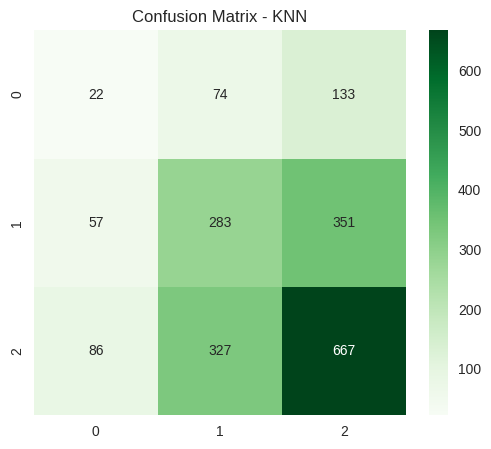

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_h, y_train_h)

y_pred_knn = knn.predict(X_test_h)

print("Accuracy KNN :", accuracy_score(y_test_h, y_pred_knn))

cm = confusion_matrix(y_test_h, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - KNN")
plt.show()

# **🟢 🔵 6️⃣ Arbre de Décision**

Accuracy Decision Tree : 0.479


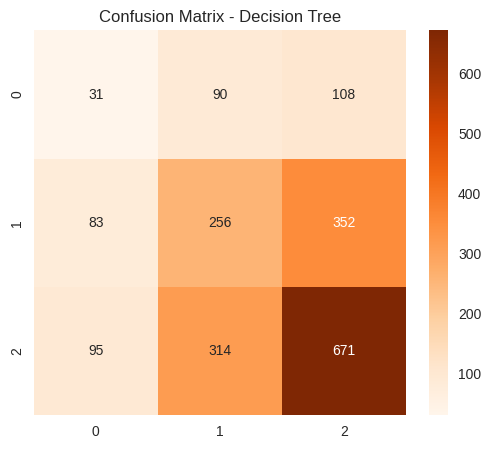

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_h, y_train_h)

y_pred_dt = dt.predict(X_test_h)

print("Accuracy Decision Tree :", accuracy_score(y_test_h, y_pred_dt))

cm = confusion_matrix(y_test_h, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# **🟢 🔵 7️⃣ Régression Linéaire**

Accuracy Régression Linéaire : 0.483
MSE : 0.5670967673290997
R² Score : -0.19779716290715044


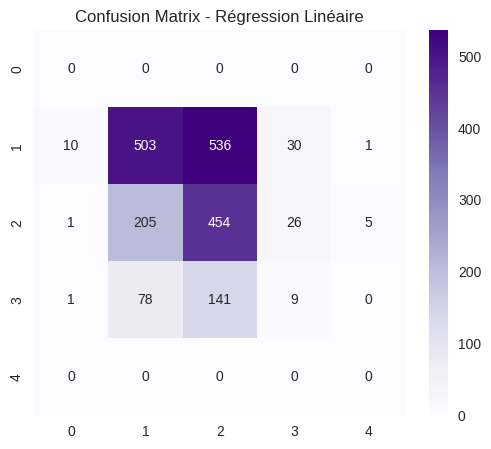

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_train_h_enc = y_train_h.replace({"NO":0, ">30":1, "<30":2})
y_test_h_enc = y_test_h.replace({"NO":0, ">30":1, "<30":2})

# Régression linéaire
lr = LinearRegression()
lr.fit(X_train_h, y_train_h_enc)

# Prédictions
y_pred_lr = lr.predict(X_test_h)

# Arrondir les prédictions pour obtenir des classes
y_pred_lr_classes = y_pred_lr.round().astype(int)

# Évaluation
print("Accuracy Régression Linéaire :", accuracy_score(y_test_h_enc, y_pred_lr_classes))
print("MSE :", mean_squared_error(y_test_h_enc, y_pred_lr))
print("R² Score :", r2_score(y_test_h_enc, y_pred_lr))

# Matrice de confusion
cm = confusion_matrix(y_test_h_enc, y_pred_lr_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - Régression Linéaire")
plt.show()


# **============================================================**
# **📊 PARTIE ÉVALUATION**
# **============================================================**

# 📊 Évaluation des Modèles

Dans cette étape, nous comparons les performances des trois modèles supervisés :

- SVM
- KNN
- Arbre de Décision

La comparaison est basée sur les métriques suivantes :

- Accuracy
- Precision
- Recall
- F1-Score
- Matrice de confusion

L’objectif est d’identifier le modèle le plus performant pour notre problème médical.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Fonction pour afficher les métriques
def evaluate_model(name, y_true, y_pred):
    print("==========", name, "==========")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1-Score :", f1_score(y_true, y_pred, average='weighted'))
    print("\n")

# Évaluation des 4 modèles
evaluate_model("SVM", y_test_h, y_pred_svm)
evaluate_model("KNN", y_test_h, y_pred_knn)
evaluate_model("Decision Tree", y_test_h, y_pred_dt)
evaluate_model("Linear Regression", y_test_h_enc, y_pred_lr_classes)


========== SVM ==========
Accuracy : 0.379
Precision: 0.4418054741635765
Recall   : 0.379
F1-Score : 0.40209619591270135


========== KNN ==========
Accuracy : 0.486
Precision: 0.4711426548742258
Recall   : 0.486
F1-Score : 0.4778937636049648


========== Decision Tree ==========
Accuracy : 0.479
Precision: 0.4713667275857838
Recall   : 0.479
F1-Score : 0.4749060402286752


========== Linear Regression ==========
Accuracy : 0.483
Precision: 0.5001151362369315
Recall   : 0.483
F1-Score : 0.47031672565963073




               Model  Accuracy  Precision  Recall  F1-Score
0                SVM     0.379   0.441805   0.379  0.402096
1                KNN     0.486   0.471143   0.486  0.477894
2      Decision Tree     0.479   0.471367   0.479  0.474906
3  Linear Regression     0.483   0.500115   0.483  0.470317


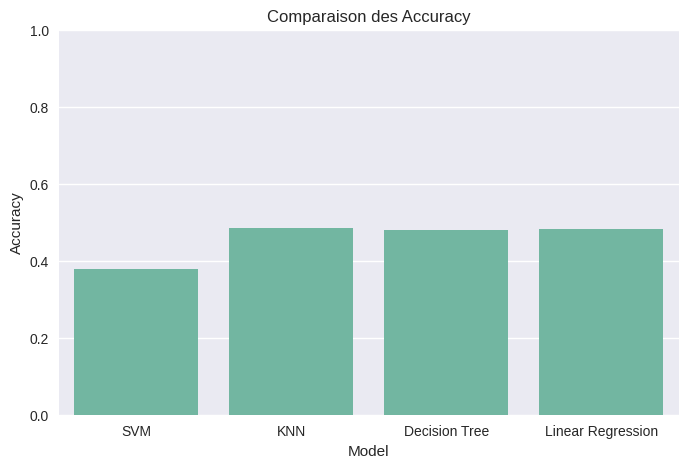

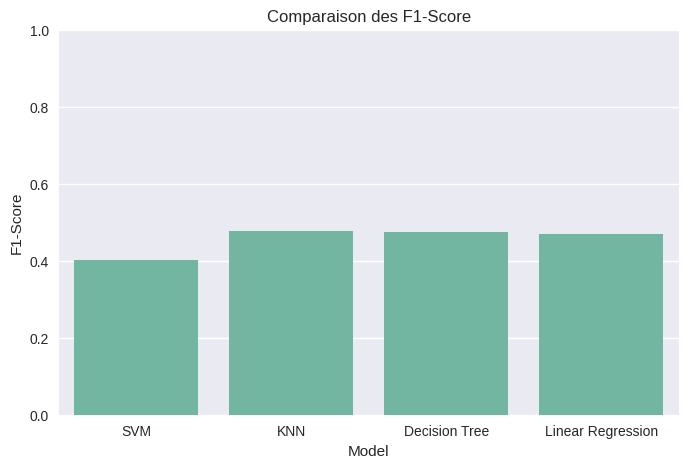

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Fonction pour calculer les métriques
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-Score": f1_score(y_true, y_pred, average='weighted')
    }

# ⚠️ Pour la régression linéaire, utiliser les cibles encodées et les prédictions arrondies
# Exemple :
# y_pred_lr_classes = y_pred_lr.round().astype(int)

# Collecte des résultats
results = pd.DataFrame([
    {"Model": "SVM", **get_metrics(y_test_h, y_pred_svm)},
    {"Model": "KNN", **get_metrics(y_test_h, y_pred_knn)},
    {"Model": "Decision Tree", **get_metrics(y_test_h, y_pred_dt)},
    {"Model": "Linear Regression", **get_metrics(y_test_h_enc, y_pred_lr_classes)}
])

print(results)

# 🔹 Visualisation Accuracy
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Comparaison des Accuracy")
plt.ylim(0,1)
plt.show()

# 🔹 Visualisation F1-Score (optionnel mais utile)
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="F1-Score", data=results)
plt.title("Comparaison des F1-Score")
plt.ylim(0,1)
plt.show()



# 🏁 Conclusion Générale du Projet

Ce projet de Machine Learning a été réalisé en suivant une méthodologie structurée :

## 1️⃣ Business Understanding
Nous avons défini deux objectifs principaux :

- 🔵 Dataset 1 : Détection du diabète (problème de classification binaire).
- 🔵 Dataset 2 : Prédiction de la réadmission hospitalière (problème de classification multi-classes).

Les objectifs ont été fixés dès le début et ne peuvent plus être modifiés.

---

## 2️⃣ Data Understanding
Une analyse exploratoire (EDA) a été réalisée afin de :

- Comprendre la structure des données
- Identifier les valeurs manquantes
- Étudier la distribution des variables
- Analyser la variable cible
- Visualiser les relations entre les variables

Cette étape nous a permis de mieux comprendre les caractéristiques des datasets avant la modélisation.

---

## 3️⃣ Data Preparation
Les données ont été nettoyées et préparées :

- Suppression des variables inutiles
- Traitement des valeurs manquantes
- Suppression des colonnes avec plus de 80% de valeurs manquantes
- Encodage des variables catégorielles
- Normalisation des données
- Séparation en ensemble d'entraînement et de test

Les données sont maintenant prêtes pour la modélisation.

---

## 4️⃣ Modeling
Plusieurs modèles ont été appliqués :

### 🔹 Modèles non supervisés :
- ACP (PCA)
- K-Means
- DBSCAN

### 🔹 Modèles supervisés :
- SVM
- KNN
- Arbre de Décision
- Régression Linéaire

Ces modèles ont permis d’analyser les données sous différents angles.

---

## 5️⃣ Évaluation et Comparaison

Les performances des modèles supervisés ont été comparées à l’aide de :

- Accuracy
- Precision
- Recall
- F1-Score
- Matrice de confusion

La comparaison a permis d’identifier le modèle le plus performant pour notre problème.

Dans un contexte médical, le F1-Score et le Recall sont particulièrement importants afin de minimiser les erreurs de classification.

---

## 🎯 Conclusion Finale

Ce projet démontre l’application complète d’un pipeline de Machine Learning :

Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation.

Les résultats obtenus montrent que les modèles de classification supervisée permettent de prédire efficacement :

- La présence du diabète
- La réadmission hospitalière

Ce travail constitue une base solide pour des améliorations futures, telles que l’optimisation des hyperparamètres et l’utilisation de techniques avancées.
